## Phase 0: Setup

In [ ]:
!pip install -q vaderSentiment wordcloud datasets

In [ ]:
import os, re, sys, collections, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer, PorterStemmer
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from datasets import load_dataset

for pkg in ["punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4"]:
    nltk.download(pkg, quiet=True)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
os.makedirs("outputs", exist_ok=True)

def save(name):
    """Save the current figure to outputs/ and display it."""
    plt.tight_layout()
    plt.savefig(f"outputs/{name}.png", dpi=150, bbox_inches="tight")
    plt.show()

## Phase 1: Load and understand the dataset

In [ ]:
ds = load_dataset("stanfordnlp/imdb")
# The dataset ships as 25K train + 25K test. For EDA we analyse all 50K together.
df = pd.concat([ds["train"].to_pandas(), ds["test"].to_pandas()], ignore_index=True)
df["sentiment"] = df["label"].map({0: "negative", 1: "positive"})

print("Shape:", df.shape)
display(df.head())
df.info()

README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 21.0MB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 20.5MB            

plain_text/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Shape: (50000, 3)


,text,label,sentiment
0,I rented I AM CURIOUS-YELLOW from my video sto...,0,negative
1,"""I Am Curious: Yellow"" is a risible and preten...",0,negative
2,If only to avoid making this type of film in t...,0,negative
3,This film was probably inspired by Godard's Ma...,0,negative
4,"Oh, brother...after hearing about this ridicul...",0,negative


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   text       50000 non-null  object
 1   label      50000 non-null  int64 
 2   sentiment  50000 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.1+ MB


sentiment
negative    25000
positive    25000
Name: count, dtype: int64


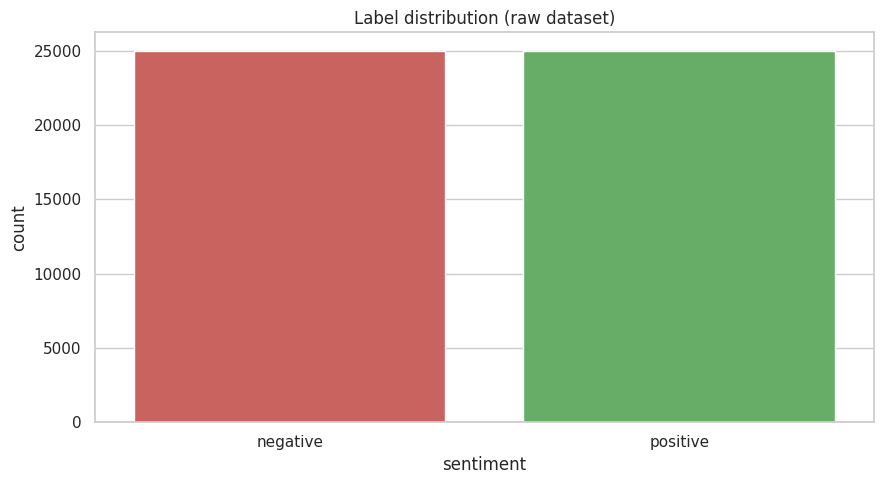

In [ ]:
print(df["sentiment"].value_counts())

sns.countplot(data=df, x="sentiment", palette=["#d9534f", "#5cb85c"])
plt.title("Label distribution (raw dataset)")
save("01_label_distribution")

## Phase 2: Data quality checks (missing, duplicate, noisy data)

In [ ]:
n = len(df)
quality = {
    "Missing values": int(df["text"].isna().sum()),
    "Empty / whitespace-only": int((df["text"].str.strip() == "").sum()),
    "Exact duplicate reviews": int(df.duplicated(subset="text").sum()),
    "Contain HTML tags": int(df["text"].str.contains(r"<[^>]+>", regex=True).sum()),
    "Contain URLs": int(df["text"].str.contains(r"http\S+|www\.\S+", regex=True).sum()),
    "Contain non-ASCII characters": int((~df["text"].apply(lambda t: t.isascii())).sum()),
    "Very short (< 10 words)": int((df["text"].str.split().str.len() < 10).sum()),
}
quality_df = pd.DataFrame(list(quality.items()), columns=["Issue", "Count"])
quality_df["% of reviews"] = (quality_df["Count"] / n * 100).round(2)
display(quality_df)

,Issue,Count,% of reviews
0,Missing values,0,0.00
1,Empty / whitespace-only,0,0.00
2,Exact duplicate reviews,418,0.84
3,Contain HTML tags,29202,58.40
4,Contain URLs,196,0.39
5,Contain non-ASCII characters,4660,9.32
6,Very short (< 10 words),5,0.01


In [ ]:
# Do duplicated texts ever carry conflicting labels?
dup_groups = df[df.duplicated(subset="text", keep=False)].groupby("text")["label"].nunique()
print("Duplicate groups with conflicting labels:", int((dup_groups > 1).sum()))

# Show noise with real examples (use these as 'before' examples in the report)
example = df[df["text"].str.contains("<br />")]["text"].iloc[0]
print("\nExample with HTML noise:\n", example[:400])

Duplicate groups with conflicting labels: 0

Example with HTML noise:
 I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student name


In [ ]:
# Remove exact duplicates (they would leak into any train/test split and bias frequencies)
before = len(df)
df = df.drop_duplicates(subset="text").reset_index(drop=True)
print(f"Removed {before - len(df)} duplicates -> {len(df)} reviews left")
print(df["sentiment"].value_counts())

Removed 418 duplicates -> 49582 reviews left
sentiment
positive    24884
negative    24698
Name: count, dtype: int64


## Phase 3: Raw-data EDA (before cleaning)

,char_len,word_len
count,49582.0,49582.0
mean,1310.6,231.4
std,990.8,171.5
min,32.0,4.0
25%,699.0,126.0
50%,971.0,173.0
75%,1592.0,281.0
max,13704.0,2470.0


,count,mean,std,min,25%,50%,75%,max
sentiment,,,,,,,,
negative,24698.0,229.6,165.1,4.0,128.0,174.0,278.0,1522.0
positive,24884.0,233.1,177.7,10.0,125.0,172.0,284.0,2470.0


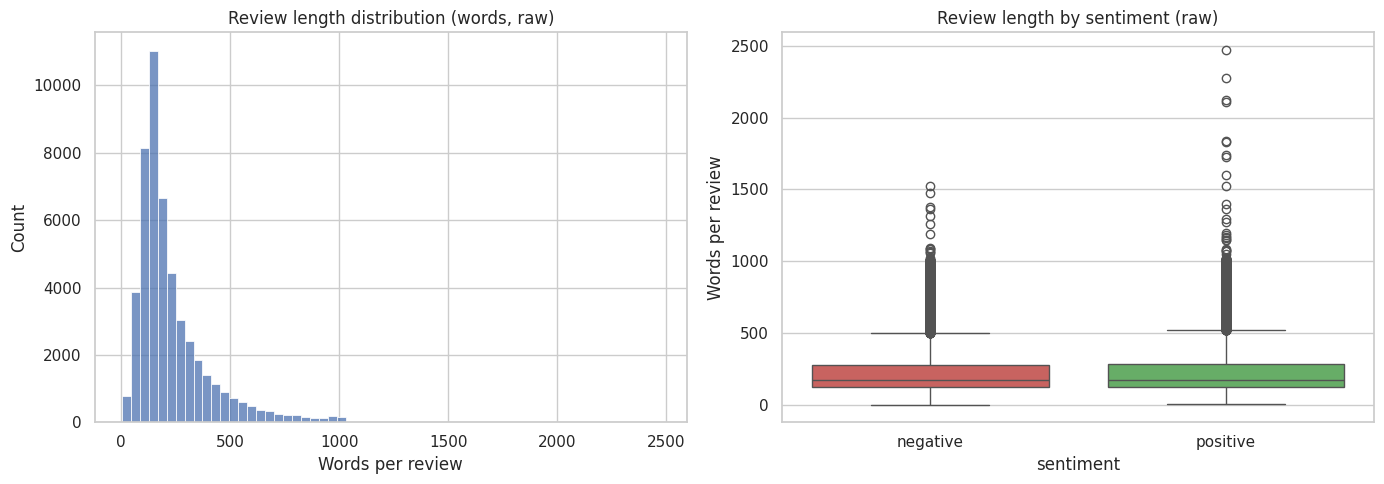

In [ ]:
df["char_len"] = df["text"].str.len()
df["word_len"] = df["text"].str.split().str.len()

display(df[["char_len", "word_len"]].describe().round(1))
display(df.groupby("sentiment")["word_len"].describe().round(1))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df["word_len"], bins=60, ax=ax[0])
ax[0].set(title="Review length distribution (words, raw)", xlabel="Words per review")
sns.boxplot(data=df, x="sentiment", y="word_len", palette=["#d9534f", "#5cb85c"], ax=ax[1])
ax[1].set(title="Review length by sentiment (raw)", ylabel="Words per review")
save("02_length_distribution_raw")

In [ ]:
# Outliers using the IQR rule
q1, q3 = df["word_len"].quantile([0.25, 0.75])
upper = q3 + 1.5 * (q3 - q1)
print(f"Upper outlier fence: {upper:.0f} words | reviews above it: {(df['word_len'] > upper).sum()}")
print("Shortest review length:", df["word_len"].min(), "words")
print("Longest review length:", df["word_len"].max(), "words")
print("\nShortest review:\n", df.loc[df["word_len"].idxmin(), "text"])

Upper outlier fence: 514 words | reviews above it: 3661
Shortest review length: 4 words
Longest review length: 2470 words

Shortest review:
 Primary plot!Primary direction!Poor interpretation.


Total tokens: 11,581,971
Unique tokens (vocabulary): 108,921
Type-token ratio: 0.0094


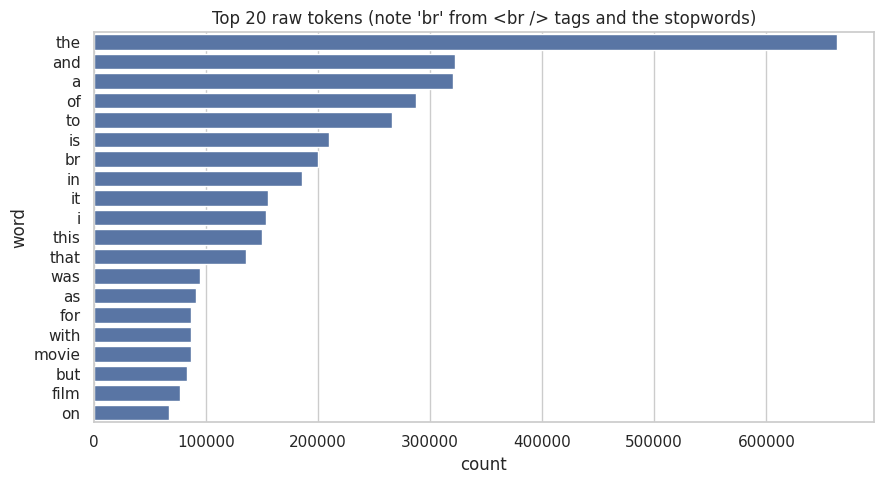

In [ ]:
# Raw vocabulary and most frequent words (no cleaning yet)
raw_tokens = df["text"].str.lower().str.findall(r"\b[a-z']+\b")
raw_counter = collections.Counter(t for toks in raw_tokens for t in toks)

total_tokens = sum(raw_counter.values())
vocab_size_raw = len(raw_counter)
print(f"Total tokens: {total_tokens:,}")
print(f"Unique tokens (vocabulary): {vocab_size_raw:,}")
print(f"Type-token ratio: {vocab_size_raw / total_tokens:.4f}")

top = pd.DataFrame(raw_counter.most_common(20), columns=["word", "count"])
sns.barplot(data=top, y="word", x="count", color="#4c72b0")
plt.title("Top 20 raw tokens (note 'br' from <br /> tags and the stopwords)")
save("03_top_words_raw")

## Phase 4: Preprocessing pipeline


In [ ]:
sample = "I didn't like this movie... it's NOT worth $10! Check http://imdb.com <br /><br />Rating: 2/10"
print("Whitespace split :", sample.split())
print("NLTK word_tokenize:", nltk.word_tokenize(sample))

Whitespace split : ['I', "didn't", 'like', 'this', 'movie...', "it's", 'NOT', 'worth', '$10!', 'Check', 'http://imdb.com', '<br', '/><br', '/>Rating:', '2/10']
NLTK word_tokenize: ['I', 'did', "n't", 'like', 'this', 'movie', '...', 'it', "'s", 'NOT', 'worth', '$', '10', '!', 'Check', 'http', ':', '//imdb.com', '<', 'br', '/', '>', '<', 'br', '/', '>', 'Rating', ':', '2/10']


In [ ]:
lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer()

# Keep negations: for sentiment, "not good" must not become "good"
NEGATIONS = {"no", "nor", "not", "never", "neither", "none", "nothing", "nowhere", "hardly", "barely"}
STOP = set(stopwords.words("english")) - NEGATIONS

CONTRACTIONS = [
    (r"won't", "will not"), (r"can't", "can not"), (r"cannot", "can not"), (r"shan't", "shall not"),
    (r"n't", " not"), (r"'re", " are"), (r"'ve", " have"), (r"'ll", " will"),
    (r"'d", " would"), (r"'m", " am"), (r"'s", ""),
]

def strip_html(t):
    return re.sub(r"<[^>]+>", " ", t)

def strip_urls(t):
    return re.sub(r"http\S+|www\.\S+", " ", t)

def expand_contractions(t):
    t = t.replace("\u2019", "'")  # curly apostrophe -> straight
    for pat, rep in CONTRACTIONS:
        t = re.sub(pat, rep, t)
    return t

def keep_alpha(t):
    t = re.sub(r"[^a-z\s]", " ", t)       # drops punctuation, digits, symbols
    return re.sub(r"\s+", " ", t).strip()

def remove_stop(t):
    return " ".join(w for w in t.split() if w not in STOP and len(w) > 1)

def lemmatize(t):
    return " ".join(lemmatizer.lemmatize(w) for w in t.split())

def stem(t):
    return " ".join(stemmer.stem(w) for w in t.split())

,Step,Vocabulary size,Avg words/review
0,0. Raw text,438729,231.4
1,1. + HTML/URL removal,412373,229.1
2,2. + Lowercasing,365227,229.1
3,3. + Contraction expansion,353754,231.2
4,4. + Punctuation/digit removal,100346,231.9
5,5. + Stopword removal (keep negations),100181,121.2
6,6a. + Lemmatization (chosen),90746,121.2
7,6b. + Stemming (alternative),69723,121.2


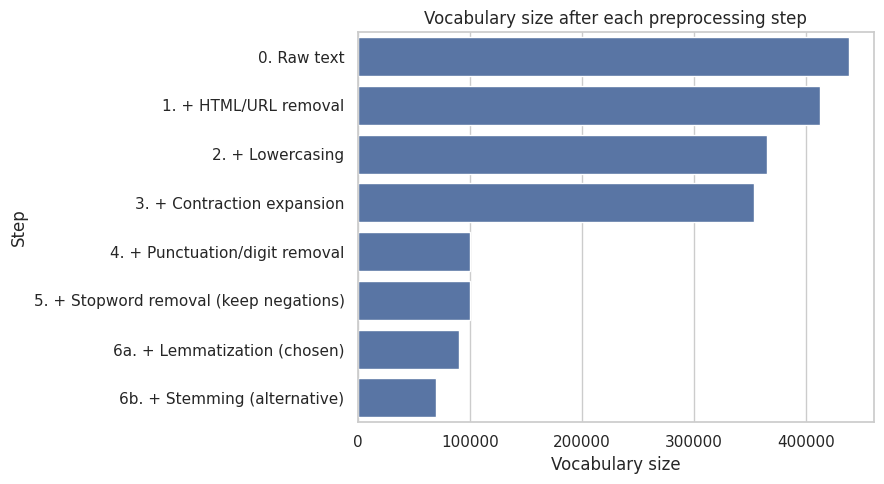

In [ ]:
# Run the pipeline step by step and record vocabulary size after every step
def vocab_size(series):
    return len({w for t in series for w in t.split()})

results = []
def record(name, series):
    results.append({"Step": name, "Vocabulary size": vocab_size(series),
                    "Avg words/review": round(series.str.split().str.len().mean(), 1)})

record("0. Raw text", df["text"])

s1 = df["text"].apply(strip_html).apply(strip_urls)
df["t_html"] = s1                       # keep case + punctuation (VADER works best on this)
record("1. + HTML/URL removal", s1)

s2 = s1.str.lower()
record("2. + Lowercasing", s2)

s3 = s2.apply(expand_contractions)
record("3. + Contraction expansion", s3)

s4 = s3.apply(keep_alpha)
df["t_alpha"] = s4                      # cleaned but stopwords still present
record("4. + Punctuation/digit removal", s4)

s5 = s4.apply(remove_stop)
record("5. + Stopword removal (keep negations)", s5)

s6 = s5.apply(lemmatize)
df["clean"] = s6
record("6a. + Lemmatization (chosen)", s6)

s7 = s5.apply(stem)
record("6b. + Stemming (alternative)", s7)

steps_df = pd.DataFrame(results)
display(steps_df)

sns.barplot(data=steps_df, y="Step", x="Vocabulary size", color="#4c72b0")
plt.title("Vocabulary size after each preprocessing step")
save("04_vocab_by_step")

In [ ]:
# Before / after example for the report
i = 3
print("RAW:\n", df.loc[i, "text"][:350], "\n")
print("1. HTML/URL removed:\n", s1[i][:350], "\n")
print("4. Lowercase + contractions + alpha only:\n", s4[i][:350], "\n")
print("5. Stopwords removed (negations kept):\n", s5[i][:350], "\n")
print("6. Lemmatized (final):\n", s6[i][:350])

RAW:
 This film was probably inspired by Godard's Masculin, féminin and I urge you to see that film instead.<br /><br />The film has two strong elements and those are, (1) the realistic acting (2) the impressive, undeservedly good, photo. Apart from that, what strikes me most is the endless stream of silliness. Lena Nyman has to be most annoying actress  

1. HTML/URL removed:
 This film was probably inspired by Godard's Masculin, féminin and I urge you to see that film instead.  The film has two strong elements and those are, (1) the realistic acting (2) the impressive, undeservedly good, photo. Apart from that, what strikes me most is the endless stream of silliness. Lena Nyman has to be most annoying actress in the wor 

4. Lowercase + contractions + alpha only:
 this film was probably inspired by godard masculin f minin and i urge you to see that film instead the film has two strong elements and those are the realistic acting the impressive undeservedly good photo apart from that w

In [ ]:
# Lemmatization vs stemming on example words
words = ["movies", "characters", "studies", "acting", "terribly", "worst", "funnier", "boring", "beautifully"]
cmp = pd.DataFrame({"word": words,
                    "lemma": [lemmatizer.lemmatize(w) for w in words],
                    "stem": [stemmer.stem(w) for w in words]})
display(cmp)

,word,lemma,stem
0,movies,movie,movi
1,characters,character,charact
2,studies,study,studi
3,acting,acting,act
4,terribly,terribly,terribl
5,worst,worst,worst
6,funnier,funnier,funnier
7,boring,boring,bore
8,beautifully,beautifully,beauti


## Phase 5: Post-cleaning EDA

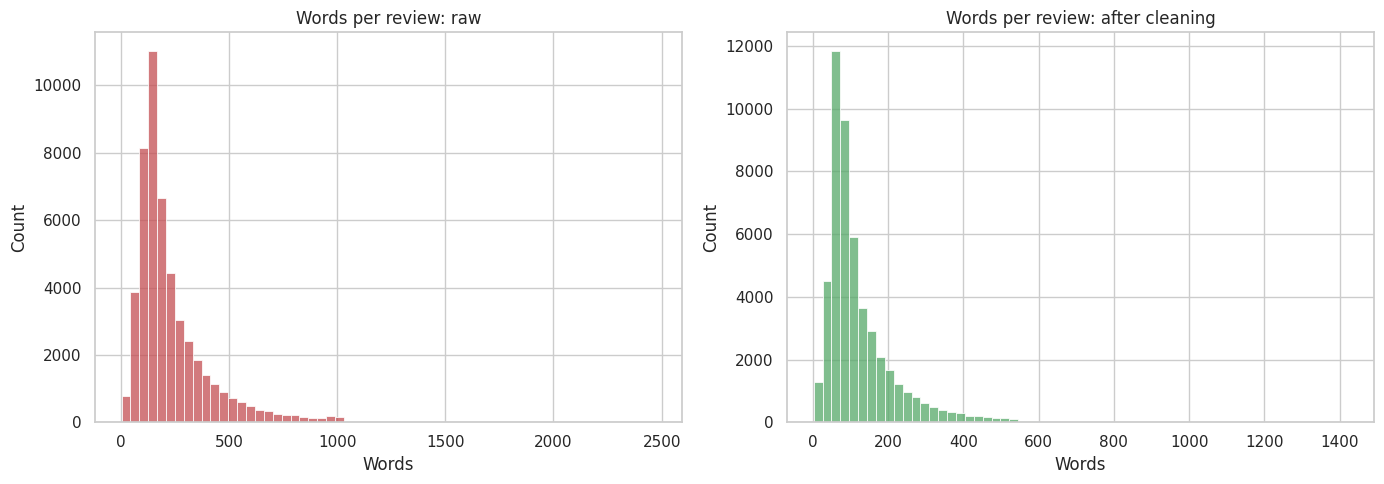

,word_len,clean_len
count,49582.0,49582.0
mean,231.4,121.2
std,171.5,91.3
min,4.0,3.0
25%,126.0,65.0
50%,173.0,90.0
75%,281.0,147.0
max,2470.0,1420.0


In [ ]:
df["clean_len"] = df["clean"].str.split().str.len()

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df["word_len"], bins=60, color="#c44e52", ax=ax[0])
ax[0].set(title="Words per review: raw", xlabel="Words")
sns.histplot(df["clean_len"], bins=60, color="#55a868", ax=ax[1])
ax[1].set(title="Words per review: after cleaning", xlabel="Words")
save("05_length_before_after")

display(df[["word_len", "clean_len"]].describe().round(1))

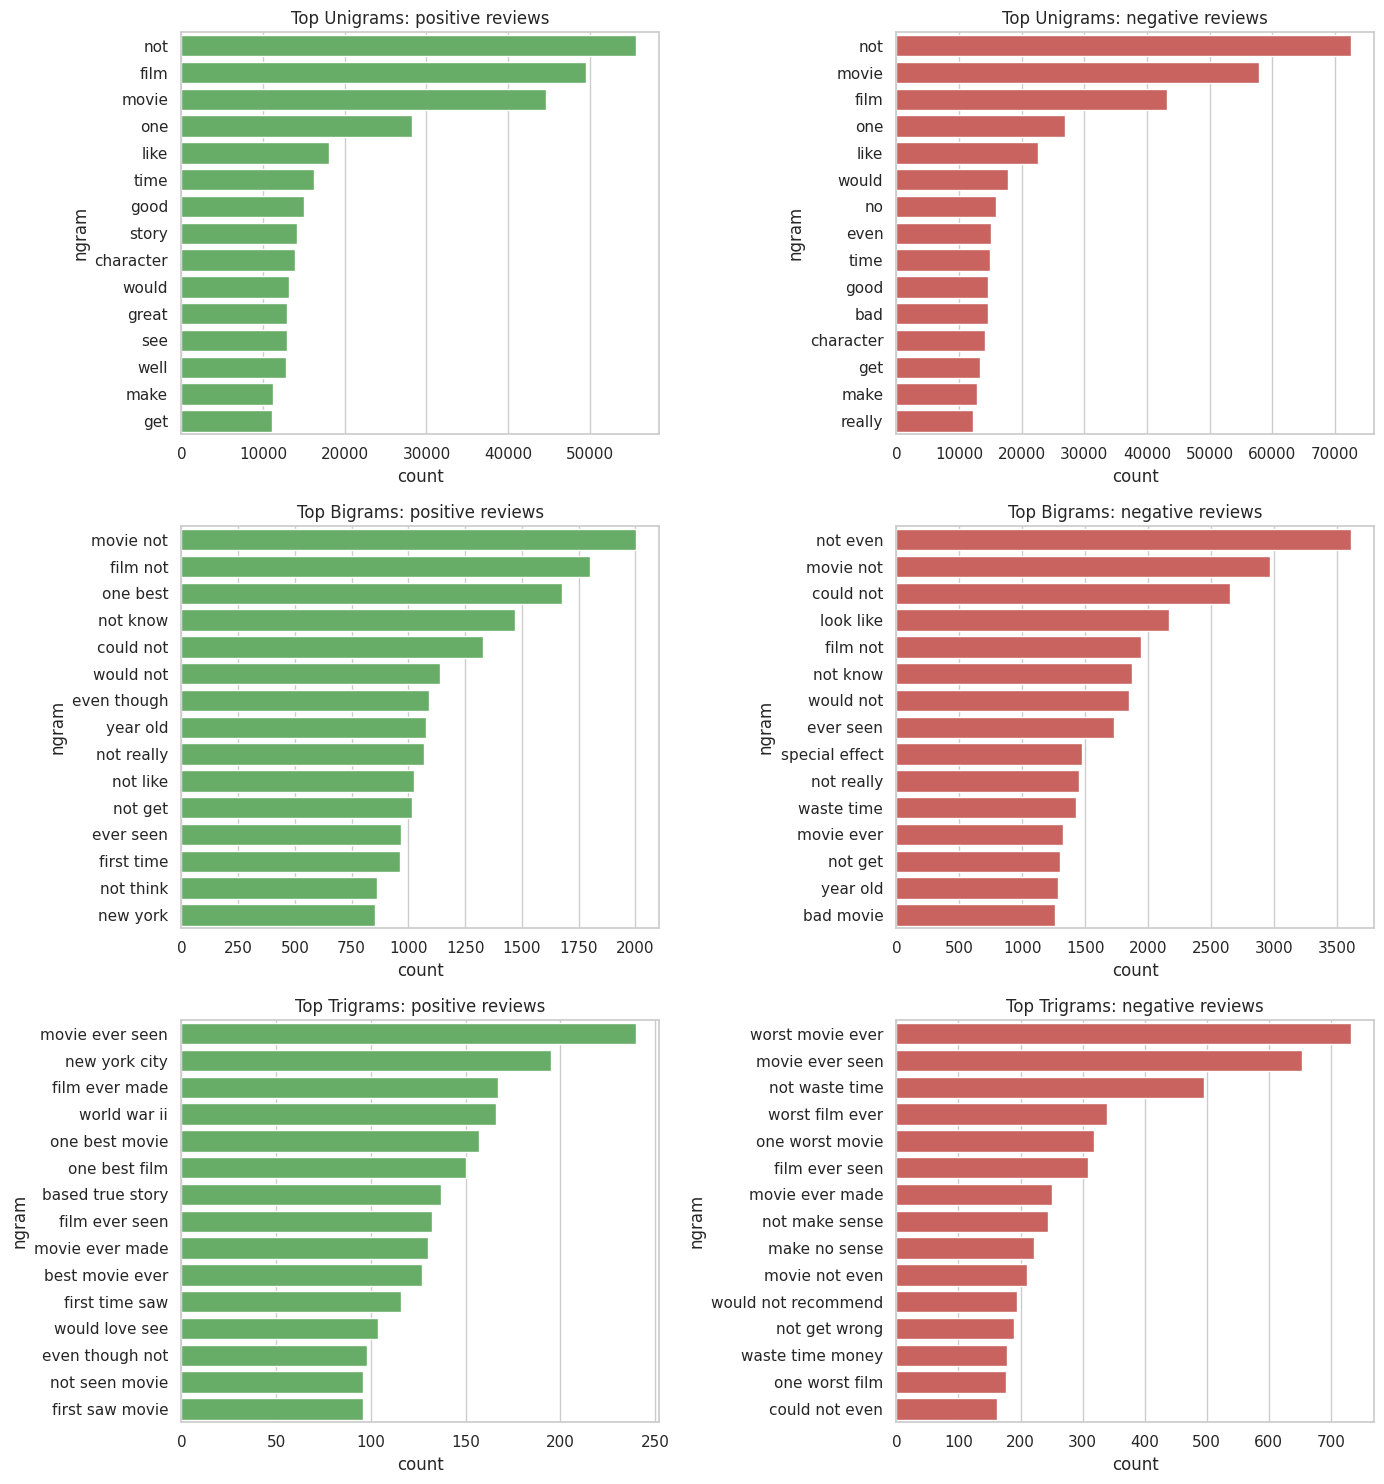

In [ ]:
# Top unigrams, bigrams, trigrams per sentiment class
def top_ngrams(texts, n, k=15, min_df=5):
    vec = CountVectorizer(ngram_range=(n, n), min_df=min_df)
    X = vec.fit_transform(texts)
    sums = np.asarray(X.sum(axis=0)).ravel()
    idx = sums.argsort()[::-1][:k]
    names = vec.get_feature_names_out()
    return pd.DataFrame({"ngram": names[idx], "count": sums[idx]})

fig, axes = plt.subplots(3, 2, figsize=(14, 15))
for row, (n, label) in enumerate([(1, "Unigrams"), (2, "Bigrams"), (3, "Trigrams")]):
    for col, (sent, color) in enumerate([("positive", "#5cb85c"), ("negative", "#d9534f")]):
        data = top_ngrams(df.loc[df["sentiment"] == sent, "clean"], n)
        sns.barplot(data=data, y="ngram", x="count", color=color, ax=axes[row, col])
        axes[row, col].set_title(f"Top {label}: {sent} reviews")
save("06_ngrams_by_class")

In [ ]:
# Effect of stopword removal on bigrams (with vs without stopwords)
with_stop = top_ngrams(df["t_alpha"], 2, k=10)
without_stop = top_ngrams(df["clean"], 2, k=10)
display(pd.concat([with_stop.add_suffix(" (with stopwords)"),
                   without_stop.add_suffix(" (stopwords removed)")], axis=1))

,ngram (with stopwords),count (with stopwords),ngram (stopwords removed),count (stopwords removed)
0,of the,76826,movie not,4967
1,in the,50120,not even,4461
2,this movie,31293,could not,3980
3,the film,26774,film not,3741
4,and the,26515,not know,3341
5,the movie,23790,would not,2987
6,to the,23574,look like,2895
7,to be,23310,ever seen,2695
8,this film,21694,not really,2519
9,it is,20657,year old,2361


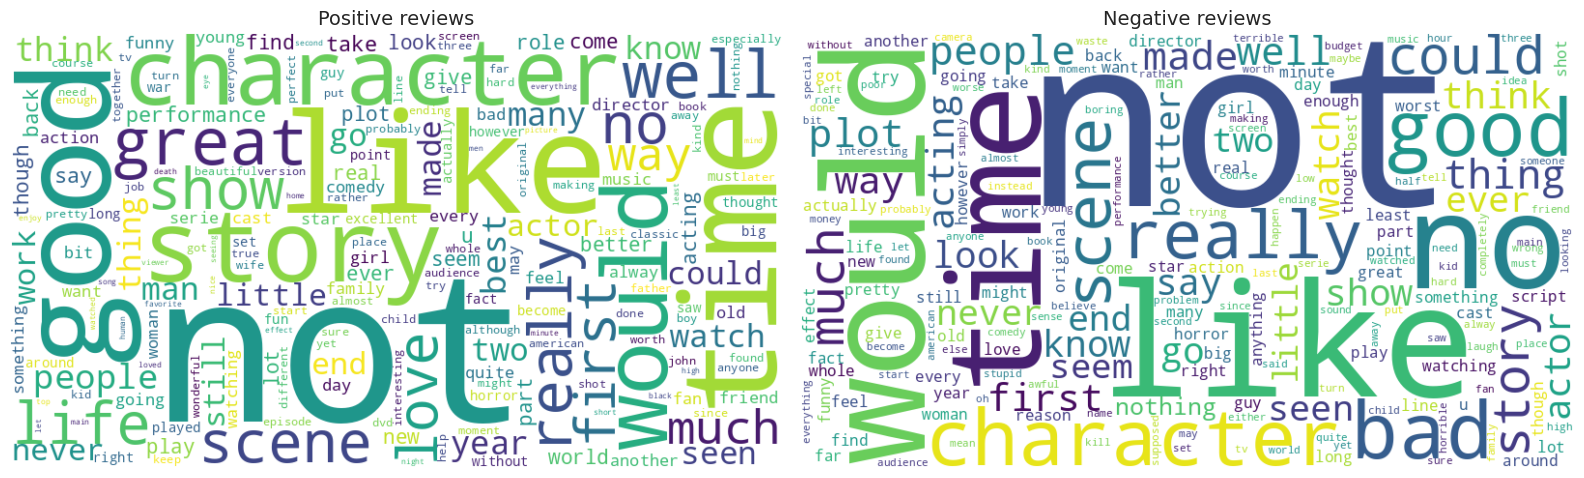

In [ ]:
# Word clouds per class ("movie"/"film"/"one" excluded: frequent but uninformative here)
extra_stop = {"movie", "film", "one", "make", "see", "get", "even", "also"}
fig, ax = plt.subplots(1, 2, figsize=(16, 7))
for a, sent in zip(ax, ["positive", "negative"]):
    text = " ".join(df.loc[df["sentiment"] == sent, "clean"])
    wc = WordCloud(width=800, height=450, background_color="white",
                   stopwords=extra_stop, collocations=False).generate(text)
    a.imshow(wc, interpolation="bilinear")
    a.axis("off")
    a.set_title(f"{sent.capitalize()} reviews", fontsize=14)
save("07_wordclouds")

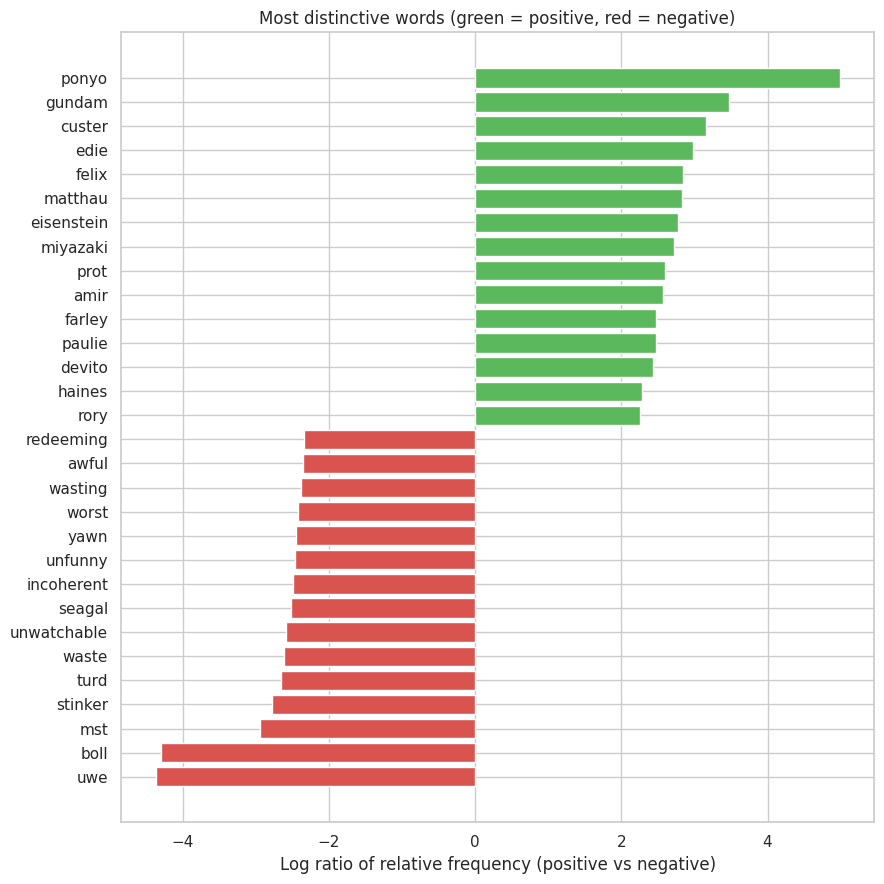

In [ ]:
# Most distinctive words per class (log ratio of relative frequencies)
cnt_pos = collections.Counter(w for t in df.loc[df["label"] == 1, "clean"] for w in t.split())
cnt_neg = collections.Counter(w for t in df.loc[df["label"] == 0, "clean"] for w in t.split())
N_pos, N_neg = sum(cnt_pos.values()), sum(cnt_neg.values())

vocab = [w for w in set(cnt_pos) | set(cnt_neg) if cnt_pos[w] + cnt_neg[w] >= 100]
score = pd.Series({w: np.log((cnt_pos[w] + 1) / N_pos) - np.log((cnt_neg[w] + 1) / N_neg) for w in vocab})
score = score.sort_values()
extremes = pd.concat([score.head(15), score.tail(15)])

colors = ["#d9534f" if v < 0 else "#5cb85c" for v in extremes.values]
plt.figure(figsize=(9, 9))
plt.barh(extremes.index, extremes.values, color=colors)
plt.title("Most distinctive words (green = positive, red = negative)")
plt.xlabel("Log ratio of relative frequency (positive vs negative)")
save("08_distinctive_words")

VADER accuracy vs true labels: 0.6987
              precision    recall  f1-score   support

    negative       0.79      0.53      0.64     24698
    positive       0.65      0.86      0.74     24884

    accuracy                           0.70     49582
   macro avg       0.72      0.70      0.69     49582
weighted avg       0.72      0.70      0.69     49582



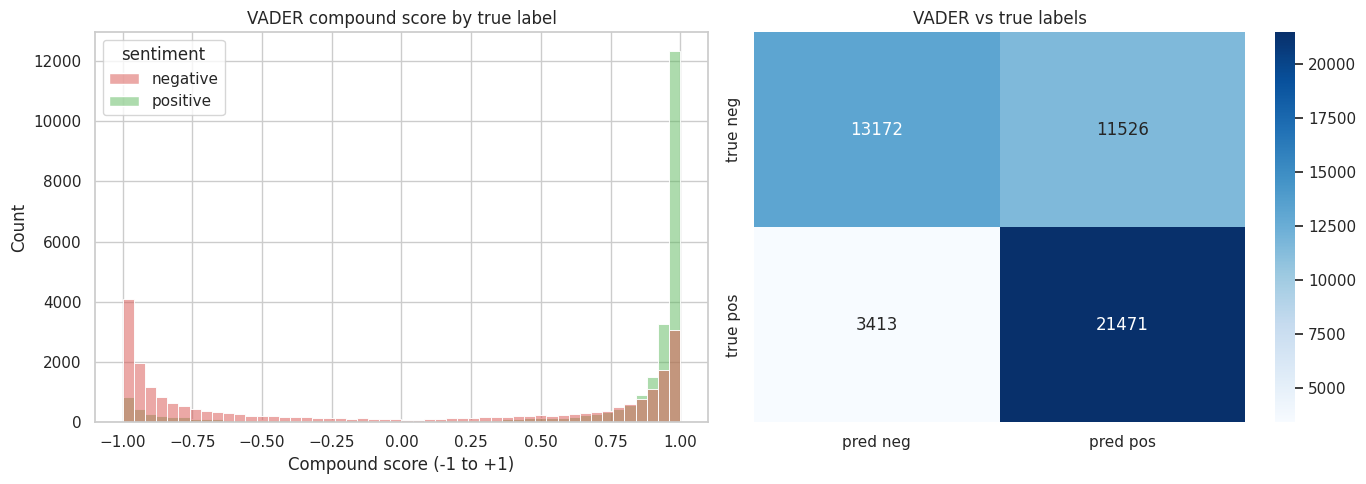

In [ ]:
sia = SentimentIntensityAnalyzer()
df["vader"] = df["t_html"].apply(lambda t: sia.polarity_scores(t)["compound"])
df["vader_pred"] = (df["vader"] >= 0).astype(int)

print("VADER accuracy vs true labels:", round(accuracy_score(df["label"], df["vader_pred"]), 4))
print(classification_report(df["label"], df["vader_pred"], target_names=["negative", "positive"]))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data=df, x="vader", hue="sentiment", bins=50, palette=["#d9534f", "#5cb85c"], ax=ax[0])
ax[0].set(title="VADER compound score by true label", xlabel="Compound score (-1 to +1)")
cm = confusion_matrix(df["label"], df["vader_pred"])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax[1],
            xticklabels=["pred neg", "pred pos"], yticklabels=["true neg", "true pos"])
ax[1].set_title("VADER vs true labels")
save("09_vader_sentiment")

In [ ]:
# Where does VADER disagree with the label? (good material for 'challenges')
wrong = df[df["label"] != df["vader_pred"]]
print(f"Disagreements: {len(wrong)} of {len(df)} ({len(wrong) / len(df):.1%})\n")
for _, r in wrong.sample(min(3, len(wrong)), random_state=42).iterrows():
    print(f"[true: {r['sentiment']} | VADER score: {r['vader']:.2f}]")
    print(r["t_html"][:350], "...\n")

Disagreements: 14939 of 49582 (30.1%)

[true: negative | VADER score: 0.90]
When someone remakes a classic movie, the remake is always unfavorably compared to the original. Also, there's a chance that the remake is so radically different that it is just too unfamiliar to audiences.  Well, the 1973 TV version of "Double Indemnity" has almost identical scenes and dialogue as the 1944 original. The main difference is that the ...

[true: negative | VADER score: 1.00]
I cannot say that Aag is the worst Bollywood film ever made, because I haven't seen every Bollywood film, but my imagination tells me that it could well be.  This film seems like an attempt at artistic suicide on behalf of the director, and I for one be believe he has been successful in his mission. No A-list actor outside of this film would risk s ...

[true: negative | VADER score: 0.43]
Imagine every stereotypical, overacted cliche from every movie and TV show set on the streets of Brooklyn between 1930 and 1980. Populate 

## Phase 6: Insights for future modelling

50th percentile length: 90 tokens
90th percentile length: 239 tokens
95th percentile length: 313 tokens
99th percentile length: 474 tokens

Vocabulary after cleaning: 90,746
Top  1,000 words cover 61.9% of all tokens
Top  5,000 words cover 85.0% of all tokens
Top 10,000 words cover 91.9% of all tokens
Top 20,000 words cover 96.5% of all tokens
Words appearing only once: 35,557 (39.2% of vocabulary)
Words appearing >= 5 times: 34,721


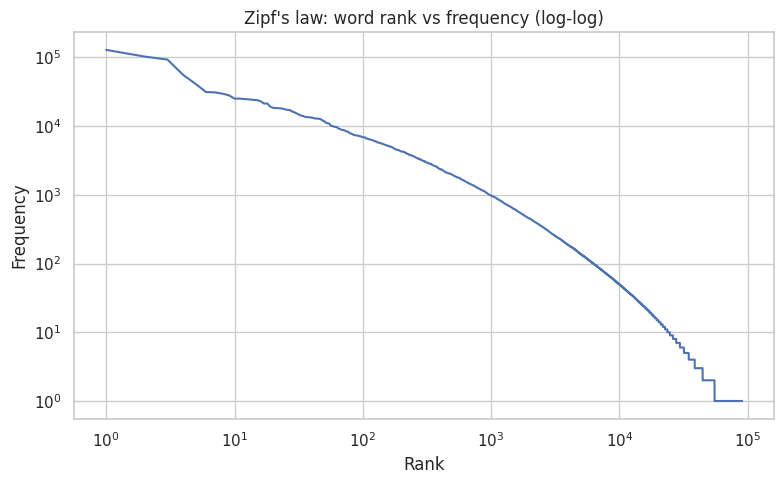

In [ ]:
# 1. Sequence length cut-offs
lens = df["clean_len"]
for p in (50, 90, 95, 99):
    print(f"{p}th percentile length: {np.percentile(lens, p):.0f} tokens")

# 2. Vocabulary coverage and long tail
freq = collections.Counter(w for t in df["clean"] for w in t.split())
counts = np.array(sorted(freq.values(), reverse=True))
total = counts.sum()
print(f"\nVocabulary after cleaning: {len(freq):,}")
for N in (1000, 5000, 10000, 20000):
    print(f"Top {N:>6,} words cover {counts[:N].sum() / total:.1%} of all tokens")
print(f"Words appearing only once: {(counts == 1).sum():,} ({(counts == 1).mean():.1%} of vocabulary)")
print(f"Words appearing >= 5 times: {(counts >= 5).sum():,}")

# 3. Zipf plot
plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(counts) + 1), counts)
plt.xscale("log"); plt.yscale("log")
plt.title("Zipf's law: word rank vs frequency (log-log)")
plt.xlabel("Rank"); plt.ylabel("Frequency")
save("10_zipf")

## Export: save cleaned data and download all charts

In [ ]:
df[["text", "clean", "label", "sentiment"]].to_csv("outputs/imdb_cleaned.csv", index=False)

print("Python:", sys.version.split()[0])
for lib in (pd, np, nltk, sns):
    print(lib.__name__, lib.__version__)
import sklearn; print("scikit-learn", sklearn.__version__)   # put these in your report appendix

Python: 3.13.15
pandas 2.2.3
numpy 2.1.3
nltk 3.9.1
seaborn 0.13.2
scikit-learn 1.6.1


In [ ]:
import shutil
shutil.make_archive("imdb_eda_outputs", "zip", "outputs")
try:
    from google.colab import files
    files.download("imdb_eda_outputs.zip")
except ImportError:
    print("Not running in Colab: find imdb_eda_outputs.zip in the working folder.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip show datasets wordcloud vaderSentiment matplotlib | grep -E "Name|Version"

Name: datasets
Version: 4.8.5
Name: wordcloud
Version: 1.9.6
Name: vaderSentiment
Version: 3.3.2
Name: matplotlib
Version: 3.10.0
